# Finance AI — Ciência de Dados do MVP

Notebook reproduzível para a entrega do Hackathon Fintech. Ele usa o dataset canônico em `finance_ai_dataset/` e grava experimentos em `ai-service/models/notebook-experiments/`; esses arquivos não são os artefatos carregados pelo runtime. O objetivo é transformar transações e indicadores financeiros em:

1. classificação automática de despesas;
2. análise do perfil financeiro;
3. métricas e explicações auditáveis;
4. modelos serializados para integração com a API.

> **Aviso:** o conjunto de dados é sintético. Os resultados demonstram a viabilidade técnica do MVP, mas não validam uso em produção sem dados reais, consentidos, anonimizados e tratados segundo a LGPD.

## 1. Escopo e critérios de validação

Este notebook cobre os entregáveis de Ciência de Dados solicitados:

- exploração e limpeza dos dados (EDA);
- tratamento de variáveis textuais e financeiras;
- engenharia de atributos e prevenção de vazamento;
- classificação de despesas;
- classificação de perfil financeiro;
- comparação, treinamento e avaliação de modelos;
- métricas por classe e matrizes de confusão;
- serialização isolada dos artefatos.

A coluna `split` do dataset é respeitada: `TRAIN` ajusta os modelos, `VALIDATION` escolhe a alternativa e `TEST` é consultado uma única vez na avaliação final. Como a divisão foi feita por usuário, também verificamos que não existe sobreposição de usuários entre os conjuntos.

### Dependências

Execute o notebook com o ambiente do `ai-service`. Se necessário:

```bash
cd ai-service
pip install -e .
pip install jupyter matplotlib
jupyter lab ../notebooks/finance_ai_data_science.ipynb
```

In [1]:
from __future__ import annotations

import json
import platform
import re
import unicodedata
import warnings
from datetime import datetime, timezone
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
try:
    from IPython.display import display
except ImportError:
    def display(value):
        print(value)
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore', category=FutureWarning)
pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', lambda value: f'{value:,.4f}')
plt.style.use('seaborn-v0_8-whitegrid')

RANDOM_STATE = 42

def find_project_root() -> Path:
    current = Path.cwd().resolve()
    for candidate in (current, *current.parents):
        if (candidate / 'ai-service').is_dir() and (candidate / 'data').is_dir():
            return candidate
    raise FileNotFoundError('Execute o notebook dentro do repositório finance-ai.')

ROOT = find_project_root()
DATA_DIR = ROOT / 'finance_ai_dataset'
ARTIFACTS_DIR = ROOT / 'ai-service' / 'models' / 'notebook-experiments'
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

print(f'Raiz do projeto: {ROOT}')
print(f'Dados: {DATA_DIR}')
print(f'Artefatos isolados: {ARTIFACTS_DIR}')
print(f'Python {platform.python_version()} | pandas {pd.__version__} | scikit-learn {sklearn.__version__}')

Raiz do projeto: C:\finance-ai
Dados: C:\finance-ai\finance_ai_dataset
Artefatos isolados: C:\finance-ai\ai-service\models\notebook-experiments
Python 3.12.10 | pandas 2.2.3 | scikit-learn 1.9.0


## 2. Carregamento e auditoria dos dados

Carregamos transações e perfis mensais diretamente das fontes versionadas. Nenhuma amostra é descartada antes da auditoria de qualidade.

In [2]:
transactions_raw = pd.read_csv(
    DATA_DIR / 'transacoes.csv',
    parse_dates=['data_transacao'],
    low_memory=False,
)
profiles_raw = pd.read_csv(DATA_DIR / 'perfis_mensais.csv', low_memory=False)

dataset_overview = pd.DataFrame({
    'dataset': ['transações', 'perfis mensais'],
    'linhas': [len(transactions_raw), len(profiles_raw)],
    'colunas': [transactions_raw.shape[1], profiles_raw.shape[1]],
    'duplicados_por_id': [
        int(transactions_raw.duplicated('transacao_id').sum()),
        int(profiles_raw.duplicated(['usuario_id', 'mes_referencia']).sum()),
    ],
})
display(dataset_overview)
display(transactions_raw.head(3))
display(profiles_raw.head(3))

,dataset,linhas,colunas,duplicados_por_id
0,transações,169546,19,0
1,perfis mensais,18000,21,0


,transacao_id,usuario_id,data_transacao,mes_referencia,descricao_original,descricao_normalizada,valor,tipo,categoria,subcategoria,estabelecimento,forma_pagamento,parcelas,recorrente,canal,estado,cidade,split,fonte
0,TX000000796,USR000008,2025-07-01,2025-07,PGTO Aluguel Residencial 3268 ALUG,pgto aluguel residencial 3268 alug,367.4200,DESPESA,MORADIA,ALUGUEL,Aluguel Residencial,PIX,1,1,POS,MG,Uberlandia,TRAIN,SINTETICO
1,TX000000801,USR000008,2025-07-01,2025-07,Microsoft 388,microsoft 388,70.7600,DESPESA,SERVICOS,ASSINATURA,Microsoft 365,DEBITO_AUTOMATICO,1,1,POS,MG,Uberlandia,TRAIN,SINTETICO
2,TX000000802,USR000008,2025-07-01,2025-07,Aluguel Residenci 502,aluguel residenci 502,417.8900,DESPESA,MORADIA,ALUGUEL,Aluguel Residencial,CARTAO_CREDITO,1,1,WEB,MG,Uberlandia,TRAIN,SINTETICO


,usuario_id,mes_referencia,renda_mensal,total_despesas,percentual_renda_comprometida,nivel_endividamento_pct,taxa_poupanca_pct,percentual_despesas_fixas,percentual_gastos_nao_essenciais,quantidade_despesas_recorrentes,quantidade_transacoes_despesa,variacao_despesas_pct,reserva_em_meses,score_financeiro,perfil_financeiro,confianca_perfil,fatores_risco,fatores_positivos,regra_rotulacao,split,fonte
0,USR000001,2025-07,"3,043.0300","2,020.3000",66.3900,0.0200,21.6200,42.8900,57.1100,3,4,0.0000,7.0800,100.0000,SAUDAVEL,0.8988,gastos_nao_essenciais_altos,despesas_controladas|baixo_endividamento|boa_t...,SCORE_SINTETICO_V1,TRAIN,SINTETICO
1,USR000002,2025-07,"4,910.8400","3,979.5700",81.0400,28.8900,5.2900,37.6200,57.4500,1,6,0.0000,3.3400,63.0000,EM_OBSERVACAO,0.7827,renda_comprometida|endividamento_moderado|baix...,reserva_adequada,SCORE_SINTETICO_V1,TRAIN,SINTETICO
2,USR000003,2025-07,"4,018.8000","4,572.8000",113.7900,71.4500,1.6700,37.9100,6.3100,4,8,0.0000,0.8600,5.0000,EM_RISCO,0.9547,despesas_acima_da_renda|endividamento_muito_al...,nenhum_relevante,SCORE_SINTETICO_V1,TRAIN,SINTETICO


In [3]:
def quality_report(frame: pd.DataFrame) -> pd.DataFrame:
    report = pd.DataFrame({
        'tipo': frame.dtypes.astype(str),
        'nulos': frame.isna().sum(),
        'nulos_pct': frame.isna().mean().mul(100),
        'unicos': frame.nunique(dropna=True),
    })
    return report.sort_values(['nulos_pct', 'unicos'], ascending=[False, True])

print('Qualidade — transações')
display(quality_report(transactions_raw).head(20))
print('Qualidade — perfis')
display(quality_report(profiles_raw).head(20))

split_audit = pd.concat([
    transactions_raw['split'].value_counts().rename('transações'),
    profiles_raw['split'].value_counts().rename('perfis'),
], axis=1).fillna(0).astype(int)
display(split_audit)

Qualidade — transações


,tipo,nulos,nulos_pct,unicos
fonte,object,0,0.0000,1
recorrente,int64,0,0.0000,2
tipo,object,0,0.0000,3
split,object,0,0.0000,3
canal,object,0,0.0000,6
parcelas,int64,0,0.0000,7
forma_pagamento,object,0,0.0000,8
mes_referencia,object,0,0.0000,12
categoria,object,0,0.0000,12
estado,object,0,0.0000,12


Qualidade — perfis


,tipo,nulos,nulos_pct,unicos
regra_rotulacao,object,0,0.0000,1
fonte,object,0,0.0000,1
perfil_financeiro,object,0,0.0000,3
split,object,0,0.0000,3
quantidade_despesas_recorrentes,int64,0,0.0000,11
quantidade_transacoes_despesa,int64,0,0.0000,11
mes_referencia,object,0,0.0000,12
fatores_positivos,object,0,0.0000,32
score_financeiro,float64,0,0.0000,90
fatores_risco,object,0,0.0000,271


,transações,perfis
split,,
TRAIN,118636,12600
VALIDATION,25478,2700
TEST,25432,2700


## 3. EDA das transações

O classificador do MVP trata somente despesas. Receitas continuam relevantes para os indicadores e para o perfil, mas não entram no target de categorias de despesa.

In [4]:
transaction_eda = pd.DataFrame({
    'indicador': [
        'período inicial', 'período final', 'usuários', 'transações',
        'receitas', 'despesas', 'valor mediano', 'valor p95',
    ],
    'valor': [
        transactions_raw['data_transacao'].min().date(),
        transactions_raw['data_transacao'].max().date(),
        transactions_raw['usuario_id'].nunique(),
        len(transactions_raw),
        int((transactions_raw['tipo'] == 'RECEITA').sum()),
        int((transactions_raw['tipo'] == 'DESPESA').sum()),
        float(transactions_raw['valor'].median()),
        float(transactions_raw['valor'].quantile(0.95)),
    ],
})
display(transaction_eda)

category_summary = (
    transactions_raw.query("tipo == 'DESPESA'")
    .groupby('categoria', observed=True)
    .agg(transacoes=('transacao_id', 'size'), valor_total=('valor', 'sum'), valor_mediano=('valor', 'median'))
    .sort_values('transacoes', ascending=False)
)
category_summary['participacao_pct'] = category_summary['transacoes'].div(category_summary['transacoes'].sum()).mul(100)
display(category_summary)

,indicador,valor
0,período inicial,2025-07-01
1,período final,2026-06-28
2,usuários,1500
3,transações,169546
4,receitas,20474
5,despesas,131313
6,valor mediano,473.6850
7,valor p95,"5,348.4475"


,transacoes,valor_total,valor_mediano,participacao_pct
categoria,,,,
MORADIA,34927,"23,224,180.0400",404.6400,26.5983
ALIMENTACAO,34431,"22,705,288.2300",404.1400,26.2206
SERVICOS,23917,"16,693,208.0700",424.2900,18.2137
TRANSPORTE,8984,"5,283,988.5400",361.3150,6.8417
LAZER,6441,"3,924,135.0800",366.6100,4.9051
SAUDE,5973,"3,586,234.8100",361.2200,4.5487
COMPRAS,5886,"3,561,316.4400",369.1350,4.4824
EDUCACAO,4831,"2,851,242.6100",364.6700,3.6790
DIVIDAS,4352,"2,823,754.4300",400.5000,3.3142


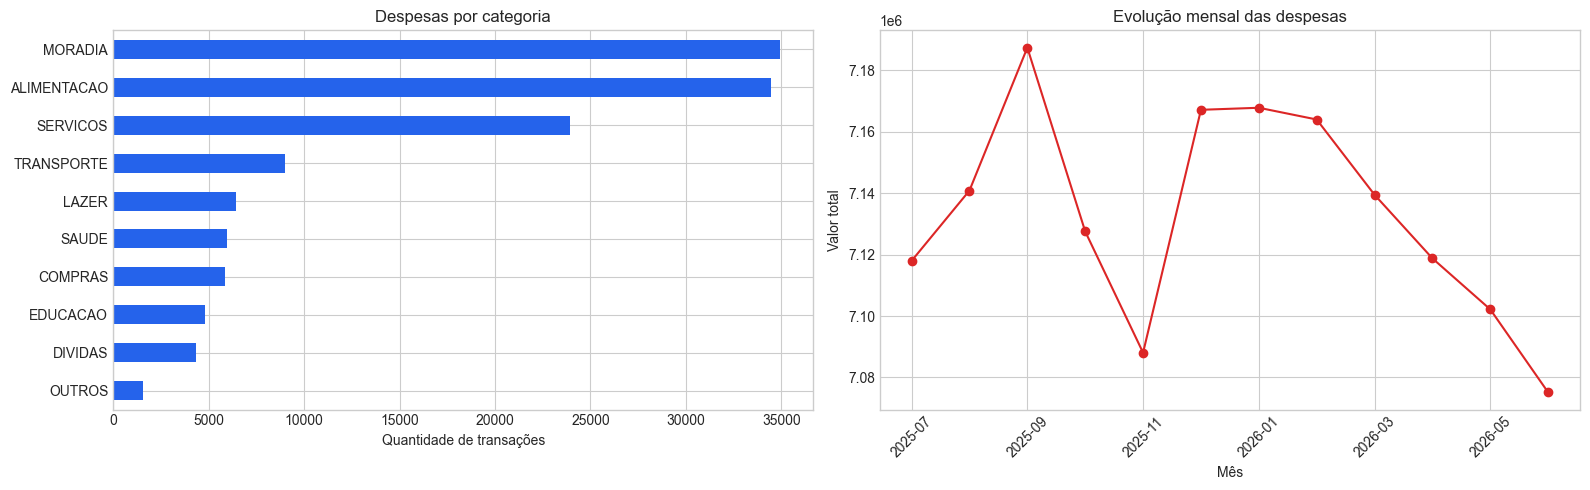

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
category_summary.sort_values('transacoes')['transacoes'].plot.barh(
    ax=axes[0], color='#2563eb', title='Despesas por categoria'
)
axes[0].set_xlabel('Quantidade de transações')
axes[0].set_ylabel('')

monthly_expenses = (
    transactions_raw.query("tipo == 'DESPESA'")
    .groupby('mes_referencia', observed=True)['valor'].sum()
)
monthly_expenses.plot(ax=axes[1], color='#dc2626', marker='o', title='Evolução mensal das despesas')
axes[1].set_xlabel('Mês')
axes[1].set_ylabel('Valor total')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## 4. Limpeza e tratamento textual

A descrição é auditada com Unicode NFKD, remoção de acentos, caixa baixa, remoção de caracteres não alfanuméricos e espaços redundantes. IDs duplicados, descrições vazias e valores não positivos são removidos. No artefato final, a normalização usa os parâmetros nativos e serializáveis do TF-IDF (`lowercase` e `strip_accents`), garantindo o mesmo tratamento em treino e inferência sem depender de funções definidas no notebook.

In [6]:
def normalize_description(value: object) -> str:
    text = '' if pd.isna(value) else str(value)
    text = unicodedata.normalize('NFKD', text)
    text = ''.join(char for char in text if not unicodedata.combining(char))
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text.lower())
    return re.sub(r'\s+', ' ', text).strip()

transactions = transactions_raw.copy()
transactions['split'] = transactions['split'].str.upper().str.strip()
transactions = transactions.query("tipo == 'DESPESA'").copy()
transactions = transactions.drop_duplicates('transacao_id')
transactions = transactions.dropna(subset=['descricao_original', 'categoria', 'valor', 'usuario_id'])
transactions = transactions.loc[transactions['valor'].gt(0)].copy()
transactions['texto_modelo'] = transactions['descricao_original'].map(normalize_description)
transactions = transactions.loc[transactions['texto_modelo'].str.len().gt(0)].copy()

cleaning_summary = {
    'despesas_originais': int((transactions_raw['tipo'] == 'DESPESA').sum()),
    'despesas_após_limpeza': len(transactions),
    'linhas_removidas': int((transactions_raw['tipo'] == 'DESPESA').sum() - len(transactions)),
    'categorias': transactions['categoria'].nunique(),
    'subcategorias': transactions['subcategoria'].nunique(),
}
display(pd.Series(cleaning_summary, name='valor').to_frame())
display(transactions[['descricao_original', 'texto_modelo', 'categoria', 'subcategoria']].sample(5, random_state=RANDOM_STATE))

,valor
despesas_originais,131313
despesas_após_limpeza,131313
linhas_removidas,0
categorias,10
subcategorias,39


,descricao_original,texto_modelo,categoria,subcategoria
136840,COMPRA Conta de Energia,compra conta de energia,MORADIA,ENERGIA
66425,LANC McDonalds CE,lanc mcdonalds ce,ALIMENTACAO,RESTAURANTE
97656,PGTO Restaurante Sabor Caseiro BA,pgto restaurante sabor caseiro ba,ALIMENTACAO,RESTAURANTE
96567,Tokio*Marine SEGU,tokio marine segu,SERVICOS,SEGURO
12218,Pao de Acucar,pao de acucar,ALIMENTACAO,SUPERMERCADO


In [7]:
transaction_splits = {
    split: transactions.loc[transactions['split'].eq(split)].copy()
    for split in ('TRAIN', 'VALIDATION', 'TEST')
}

def assert_user_isolation(splits: dict[str, pd.DataFrame]) -> None:
    users = {name: set(frame['usuario_id']) for name, frame in splits.items()}
    for left, right in (('TRAIN', 'VALIDATION'), ('TRAIN', 'TEST'), ('VALIDATION', 'TEST')):
        overlap = users[left].intersection(users[right])
        assert not overlap, f'Vazamento de usuários entre {left} e {right}: {len(overlap)}'

assert_user_isolation(transaction_splits)
display(pd.DataFrame({
    name: {'linhas': len(frame), 'usuarios': frame['usuario_id'].nunique()}
    for name, frame in transaction_splits.items()
}).T)
print('[OK] Não há usuários compartilhados entre TRAIN, VALIDATION e TEST.')

,linhas,usuarios
TRAIN,91882,1050
VALIDATION,19739,225
TEST,19692,225


[OK] Não há usuários compartilhados entre TRAIN, VALIDATION e TEST.


## 5. Classificador de despesas

O baseline combina TF-IDF de unigramas e bigramas com Regressão Logística balanceada. Essa arquitetura é adequada ao MVP por ser rápida, serializável e explicável por coeficientes. O conjunto `TEST` permanece intocado até a avaliação final.

In [8]:
transaction_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        lowercase=True,
        strip_accents='unicode',
        ngram_range=(1, 2),
        min_df=2,
        max_features=20_000,
        sublinear_tf=True,
    )),
    ('classifier', LogisticRegression(
        class_weight='balanced',
        max_iter=1_000,
        random_state=RANDOM_STATE,
    )),
])

tx_train = transaction_splits['TRAIN']
tx_validation = transaction_splits['VALIDATION']
tx_test = transaction_splits['TEST']

transaction_pipeline.fit(tx_train['descricao_original'], tx_train['categoria'])
print(f'Vocabulário TF-IDF: {len(transaction_pipeline.named_steps["tfidf"].vocabulary_):,} termos')

Vocabulário TF-IDF: 4,974 termos


In [9]:
def to_builtin(value):
    if isinstance(value, dict):
        return {str(key): to_builtin(item) for key, item in value.items()}
    if isinstance(value, (list, tuple)):
        return [to_builtin(item) for item in value]
    if isinstance(value, np.ndarray):
        return value.tolist()
    if isinstance(value, (np.integer, np.floating)):
        return value.item()
    return value

def evaluate_model(model, X, y, labels: list[str], split_name: str):
    predictions = model.predict(X)
    report = classification_report(y, predictions, output_dict=True, zero_division=0)
    metrics = {
        'split': split_name,
        'samples': len(y),
        'accuracy': accuracy_score(y, predictions),
        'macro_f1': f1_score(y, predictions, average='macro', zero_division=0),
        'weighted_f1': f1_score(y, predictions, average='weighted', zero_division=0),
        'classification_report': report,
        'confusion_matrix': confusion_matrix(y, predictions, labels=labels),
        'labels': labels,
    }
    summary = pd.Series({key: metrics[key] for key in ('samples', 'accuracy', 'macro_f1', 'weighted_f1')}, name=split_name)
    display(summary.to_frame())
    display(pd.DataFrame(report).T.round(4))
    return to_builtin(metrics), predictions

transaction_labels = sorted(transactions['categoria'].unique())
tx_validation_metrics, tx_validation_predictions = evaluate_model(
    transaction_pipeline, tx_validation['descricao_original'], tx_validation['categoria'],
    transaction_labels, 'VALIDATION',
)

,VALIDATION
samples,"19,739.0000"
accuracy,0.9998
macro_f1,0.9997
weighted_f1,0.9998


,precision,recall,f1-score,support
ALIMENTACAO,1.0000,0.9994,0.9997,"5,194.0000"
COMPRAS,0.9967,1.0000,0.9983,906.0000
DIVIDAS,1.0000,1.0000,1.0000,605.0000
EDUCACAO,1.0000,1.0000,1.0000,732.0000
LAZER,1.0000,0.9990,0.9995,959.0000
MORADIA,1.0000,1.0000,1.0000,"5,200.0000"
OUTROS,1.0000,1.0000,1.0000,250.0000
SAUDE,1.0000,1.0000,1.0000,927.0000
SERVICOS,1.0000,1.0000,1.0000,"3,594.0000"
TRANSPORTE,0.9993,1.0000,0.9996,"1,372.0000"


### Avaliação final do classificador

Após validar a arquitetura, o modelo final é reajustado com `TRAIN + VALIDATION`. Somente então o conjunto `TEST` é usado para a métrica final.

,TEST
samples,"19,692.0000"
accuracy,0.9999
macro_f1,0.9999
weighted_f1,0.9999


,precision,recall,f1-score,support
ALIMENTACAO,1.0000,0.9996,0.9998,"5,150.0000"
COMPRAS,0.9977,1.0000,0.9988,850.0000
DIVIDAS,1.0000,1.0000,1.0000,700.0000
EDUCACAO,1.0000,1.0000,1.0000,707.0000
LAZER,1.0000,1.0000,1.0000,966.0000
MORADIA,1.0000,1.0000,1.0000,"5,275.0000"
OUTROS,1.0000,1.0000,1.0000,240.0000
SAUDE,1.0000,1.0000,1.0000,851.0000
SERVICOS,1.0000,1.0000,1.0000,"3,576.0000"
TRANSPORTE,1.0000,1.0000,1.0000,"1,377.0000"


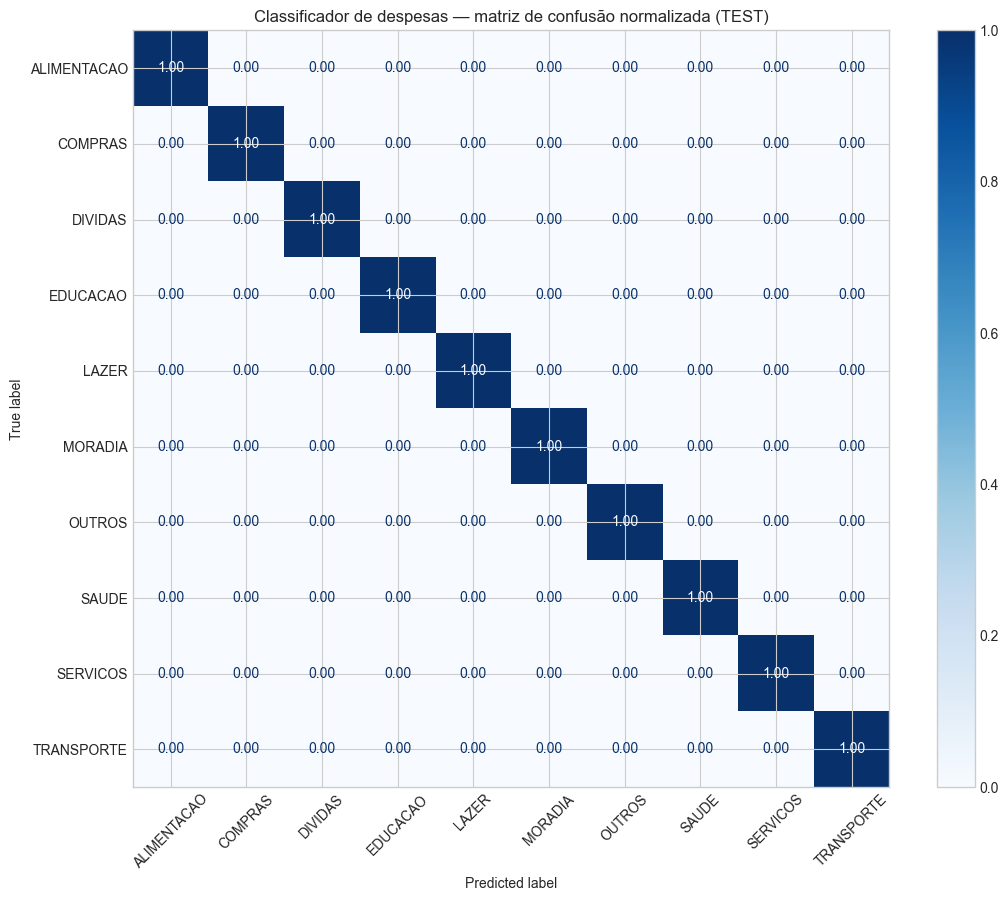

In [10]:
transaction_final = clone(transaction_pipeline)
tx_train_validation = pd.concat([tx_train, tx_validation], ignore_index=True)
transaction_final.fit(tx_train_validation['descricao_original'], tx_train_validation['categoria'])
tx_test_metrics, tx_test_predictions = evaluate_model(
    transaction_final, tx_test['descricao_original'], tx_test['categoria'],
    transaction_labels, 'TEST',
)

fig, ax = plt.subplots(figsize=(11, 9))
ConfusionMatrixDisplay.from_predictions(
    tx_test['categoria'], tx_test_predictions, labels=transaction_labels,
    normalize='true', cmap='Blues', xticks_rotation=45, values_format='.2f', ax=ax,
)
ax.set_title('Classificador de despesas — matriz de confusão normalizada (TEST)')
plt.tight_layout()
plt.show()

In [11]:
tx_error_analysis = tx_test[['descricao_original', 'categoria']].copy()
tx_error_analysis['predicao'] = tx_test_predictions
tx_error_analysis['confianca'] = transaction_final.predict_proba(tx_test['descricao_original']).max(axis=1)
tx_errors = tx_error_analysis.loc[tx_error_analysis['categoria'].ne(tx_error_analysis['predicao'])]
print(f'Erros no conjunto TEST: {len(tx_errors):,} de {len(tx_test):,}')
display(tx_errors.sort_values('confianca').head(20))

realistic_examples = pd.Series([
    'Supermercado Extra compra do mês',
    'Abastecimento posto Shell gasolina',
    'Mensalidade Netflix',
], name='descricao')
example_predictions = transaction_final.predict(realistic_examples)
example_probabilities = transaction_final.predict_proba(realistic_examples).max(axis=1)
display(pd.DataFrame({
    'descricao': realistic_examples,
    'categoria_prevista': example_predictions,
    'confianca': example_probabilities,
}))

Erros no conjunto TEST: 2 de 19,692


,descricao_original,categoria,predicao,confianca
131109,4taca 348,ALIMENTACAO,COMPRAS,0.2286
162618,4tacad 176,ALIMENTACAO,COMPRAS,0.2439


,descricao,categoria_prevista,confianca
0,Supermercado Extra compra do mês,ALIMENTACAO,0.9954
1,Abastecimento posto Shell gasolina,TRANSPORTE,0.9988
2,Mensalidade Netflix,LAZER,0.9952


### Explicabilidade textual

Os termos abaixo vêm dos coeficientes reais da Regressão Logística para cada categoria. Diferentemente de apenas repetir palavras da entrada, eles mostram quais atributos TF-IDF mais aumentam a probabilidade de cada classe.

In [12]:
tfidf = transaction_final.named_steps['tfidf']
tx_classifier = transaction_final.named_steps['classifier']
feature_names = np.asarray(tfidf.get_feature_names_out())
top_terms_by_category = {}
for class_index, category in enumerate(tx_classifier.classes_):
    top_indices = np.argsort(tx_classifier.coef_[class_index])[-12:][::-1]
    top_terms_by_category[category] = feature_names[top_indices].tolist()
display(pd.DataFrame(top_terms_by_category).T.rename_axis('categoria').rename(columns=lambda index: f'termo_{index + 1}'))

,termo_1,termo_2,termo_3,termo_4,termo_5,termo_6,termo_7,termo_8,termo_9,termo_10,termo_11,termo_12
categoria,,,,,,,,,,,,
ALIMENTACAO,starbucks,supermercado,carrefour,ifood,mcdonalds,outback,atacadao,burger,cafeteria,padaria,ifoo,assai
COMPRAS,madeiramadeira,zara,boticario,havan,kabum,sephora,natura,riachuelo,renner,tok,shein,amazon
DIVIDAS,fatura,financiamento,emprestimo,parcela,credito,f4tura,veiculo,imovel,fin4nciamento,credito pessoal,pessoal,emprestimo consignado
EDUCACAO,wizard,universidade,saraiva,faculdade,cultura,coursera,alura,udemy,livros,open,escola,udem
LAZER,xbox,cinemark,max,sympla,ticketmaster,kinoplex,steam,nintendo,booking,netflix,airbnb,decolar
MORADIA,edp,enel,supergasbras,ultragaz,sabesp,cemig,residencial,imobiliaria,saneamento,administradora,condominio,cemi
OUTROS,saque,contribuicao,anuidade,doacao,tarifa,contribuica,contribui,contribuic,taxa,anuida,anuidad,4nuidade
SAUDE,amil,raia,hapvida,drogasil,unimed,clinica,diagnosticos,consulta,laboratorio,pague,saude,unim
SERVICOS,tim,oi,vivo,claro,dropbox,microsoft,google,adobe,tokio,adob,porto,azul


In [13]:
transaction_artifact = ARTIFACTS_DIR / 'transaction_classifier.joblib'
joblib.dump(transaction_final, transaction_artifact)
print(f'Classificador serializado em: {transaction_artifact}')

Classificador serializado em: C:\finance-ai\ai-service\models\notebook-experiments\transaction_classifier.joblib


## 6. Análise do perfil financeiro

O target possui três classes: `SAUDAVEL`, `EM_OBSERVACAO` e `EM_RISCO`. As variáveis `score_financeiro`, `confianca_perfil`, `fatores_risco`, `fatores_positivos` e `regra_rotulacao` são proibidas, pois foram geradas junto ao rótulo e causariam vazamento de dados.

In [14]:
PROFILE_FEATURES = [
    'percentual_renda_comprometida',
    'nivel_endividamento_pct',
    'taxa_poupanca_pct',
    'percentual_despesas_fixas',
    'percentual_gastos_nao_essenciais',
    'quantidade_despesas_recorrentes',
    'quantidade_transacoes_despesa',
    'variacao_despesas_pct',
    'reserva_em_meses',
]
FORBIDDEN_FEATURES = {
    'score_financeiro', 'confianca_perfil', 'fatores_risco',
    'fatores_positivos', 'regra_rotulacao', 'perfil_financeiro',
}
assert not FORBIDDEN_FEATURES.intersection(PROFILE_FEATURES)

profiles = profiles_raw.copy()
profiles['split'] = profiles['split'].str.upper().str.strip()
profiles = profiles.drop_duplicates(['usuario_id', 'mes_referencia'])
profiles = profiles.dropna(subset=[*PROFILE_FEATURES, 'perfil_financeiro', 'usuario_id'])

profile_splits = {
    split: profiles.loc[profiles['split'].eq(split)].copy()
    for split in ('TRAIN', 'VALIDATION', 'TEST')
}
assert_user_isolation(profile_splits)

display(profiles[PROFILE_FEATURES].describe().T)
display(pd.crosstab(profiles['split'], profiles['perfil_financeiro'], margins=True))
print('[OK] Features de vazamento excluídas e usuários isolados entre os splits.')

,count,mean,std,min,25%,50%,75%,max
percentual_renda_comprometida,"18,000.0000",81.2084,17.6849,39.4800,67.8075,79.8100,93.6325,131.7300
nivel_endividamento_pct,"18,000.0000",31.0105,19.8410,0.0000,16.5400,28.2100,43.0150,96.4200
taxa_poupanca_pct,"18,000.0000",9.1577,6.0483,0.0000,3.9700,8.3850,13.5200,22.0000
percentual_despesas_fixas,"18,000.0000",49.6516,21.0367,1.4400,33.6175,48.7050,64.8100,99.9000
percentual_gastos_nao_essenciais,"18,000.0000",26.4737,20.0934,0.0000,10.1100,23.6400,39.7900,96.6900
quantidade_despesas_recorrentes,"18,000.0000",3.2177,1.4848,0.0000,2.0000,3.0000,4.0000,10.0000
quantidade_transacoes_despesa,"18,000.0000",7.2952,2.4753,4.0000,5.0000,7.0000,9.0000,14.0000
variacao_despesas_pct,"18,000.0000",1.4914,18.0106,-50.2000,-10.4600,0.0000,11.6700,108.5800
reserva_em_meses,"18,000.0000",5.7313,5.9075,0.0000,1.2875,3.6800,8.6900,74.2800


perfil_financeiro,EM_OBSERVACAO,EM_RISCO,SAUDAVEL,All
split,,,,
TEST,816,833,1051,2700
TRAIN,3972,3622,5006,12600
VALIDATION,730,751,1219,2700
All,5518,5206,7276,18000


[OK] Features de vazamento excluídas e usuários isolados entre os splits.


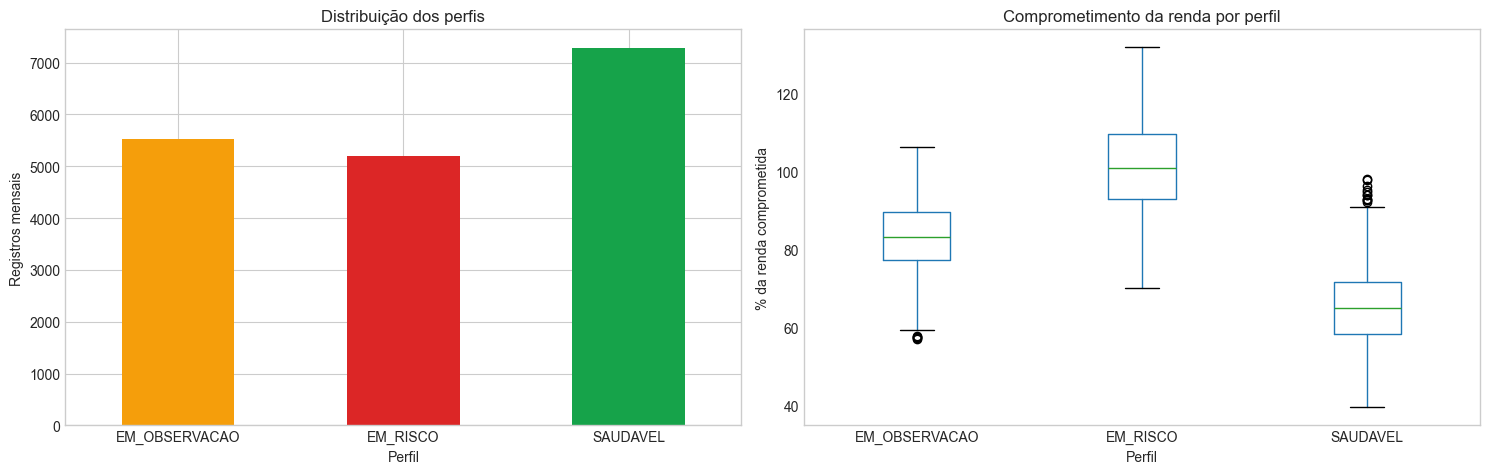

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
profiles['perfil_financeiro'].value_counts().sort_index().plot.bar(
    ax=axes[0], color=['#f59e0b', '#dc2626', '#16a34a'], title='Distribuição dos perfis'
)
axes[0].set_xlabel('Perfil')
axes[0].set_ylabel('Registros mensais')
axes[0].tick_params(axis='x', rotation=0)

profiles.boxplot(
    column='percentual_renda_comprometida', by='perfil_financeiro',
    ax=axes[1], grid=False,
)
axes[1].set_title('Comprometimento da renda por perfil')
axes[1].set_xlabel('Perfil')
axes[1].set_ylabel('% da renda comprometida')
plt.suptitle('')
plt.tight_layout()
plt.show()

## 7. Comparação de modelos de perfil

Comparamos Regressão Logística e Random Forest. A escolha é feita exclusivamente pelo macro F1 de `VALIDATION`, que dá peso igual às três classes.

In [16]:
profile_candidates = {
    'LogisticRegression': Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', LogisticRegression(
            class_weight='balanced', max_iter=1_000, random_state=RANDOM_STATE,
        )),
    ]),
    'RandomForest': RandomForestClassifier(
        n_estimators=250,
        min_samples_leaf=2,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
}

profile_train = profile_splits['TRAIN']
profile_validation = profile_splits['VALIDATION']
profile_test = profile_splits['TEST']
profile_labels = sorted(profiles['perfil_financeiro'].unique())

validation_rows = []
fitted_candidates = {}
for model_name, candidate in profile_candidates.items():
    fitted = clone(candidate).fit(profile_train[PROFILE_FEATURES], profile_train['perfil_financeiro'])
    predictions = fitted.predict(profile_validation[PROFILE_FEATURES])
    validation_rows.append({
        'modelo': model_name,
        'accuracy': accuracy_score(profile_validation['perfil_financeiro'], predictions),
        'macro_f1': f1_score(profile_validation['perfil_financeiro'], predictions, average='macro'),
        'weighted_f1': f1_score(profile_validation['perfil_financeiro'], predictions, average='weighted'),
    })
    fitted_candidates[model_name] = fitted

profile_validation_comparison = pd.DataFrame(validation_rows).sort_values('macro_f1', ascending=False)
display(profile_validation_comparison)
selected_profile_model_name = profile_validation_comparison.iloc[0]['modelo']
print(f'Modelo selecionado por macro F1: {selected_profile_model_name}')

,modelo,accuracy,macro_f1,weighted_f1
1,RandomForest,0.9881,0.9873,0.9882
0,LogisticRegression,0.9248,0.9171,0.9257


Modelo selecionado por macro F1: RandomForest


,TEST
samples,"2,700.0000"
accuracy,0.9889
macro_f1,0.9887
weighted_f1,0.9889


,precision,recall,f1-score,support
EM_OBSERVACAO,0.9701,0.9939,0.9818,816.0000
EM_RISCO,0.9940,0.9916,0.9928,833.0000
SAUDAVEL,1.0000,0.9829,0.9914,"1,051.0000"
accuracy,0.9889,0.9889,0.9889,0.9889
macro avg,0.9880,0.9894,0.9887,"2,700.0000"
weighted avg,0.9891,0.9889,0.9889,"2,700.0000"


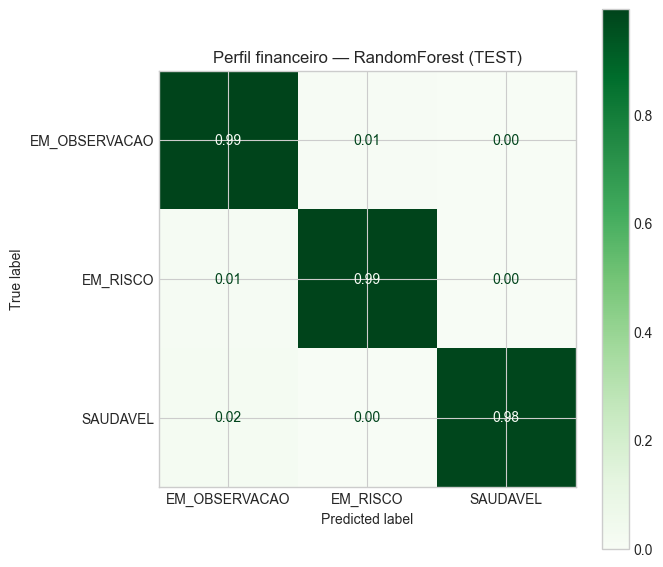

In [17]:
profile_train_validation = pd.concat([profile_train, profile_validation], ignore_index=True)
profile_final = clone(profile_candidates[selected_profile_model_name])
profile_final.fit(profile_train_validation[PROFILE_FEATURES], profile_train_validation['perfil_financeiro'])
profile_test_metrics, profile_test_predictions = evaluate_model(
    profile_final, profile_test[PROFILE_FEATURES], profile_test['perfil_financeiro'],
    profile_labels, 'TEST',
)

fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(
    profile_test['perfil_financeiro'], profile_test_predictions, labels=profile_labels,
    normalize='true', cmap='Greens', values_format='.2f', ax=ax,
)
ax.set_title(f'Perfil financeiro — {selected_profile_model_name} (TEST)')
plt.tight_layout()
plt.show()

### Explicabilidade do perfil

A importância global abaixo permite explicar quais indicadores mais influenciam o modelo selecionado. SHAP não está instalado nem integrado ao projeto atual; qualquer adoção futura exigirá dependência, validação e versionamento próprios.

,feature,importance
2,taxa_poupanca_pct,0.3033
8,reserva_em_meses,0.2691
0,percentual_renda_comprometida,0.2144
1,nivel_endividamento_pct,0.1475
4,percentual_gastos_nao_essenciais,0.0396
7,variacao_despesas_pct,0.0104
3,percentual_despesas_fixas,0.0097
6,quantidade_transacoes_despesa,0.0034
5,quantidade_despesas_recorrentes,0.0027


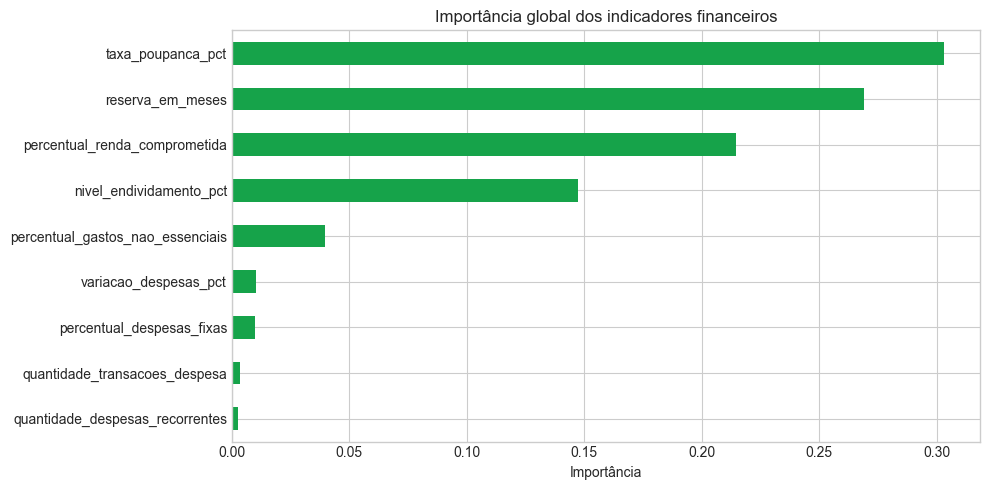

In [18]:
if hasattr(profile_final, 'feature_importances_'):
    profile_importance_values = profile_final.feature_importances_
elif isinstance(profile_final, Pipeline):
    coefficients = profile_final.named_steps['classifier'].coef_
    profile_importance_values = np.abs(coefficients).mean(axis=0)
else:
    profile_importance_values = np.zeros(len(PROFILE_FEATURES))

profile_importance = (
    pd.DataFrame({'feature': PROFILE_FEATURES, 'importance': profile_importance_values})
    .sort_values('importance', ascending=True)
)
display(profile_importance.sort_values('importance', ascending=False))
profile_importance.plot.barh(x='feature', y='importance', figsize=(10, 5), color='#16a34a', legend=False)
plt.title('Importância global dos indicadores financeiros')
plt.xlabel('Importância')
plt.ylabel('')
plt.tight_layout()
plt.show()

In [19]:
profile_artifact = ARTIFACTS_DIR / 'profile_classifier.joblib'
joblib.dump(profile_final, profile_artifact)
with (ARTIFACTS_DIR / 'profile_feature_names.json').open('w', encoding='utf-8') as file:
    json.dump(PROFILE_FEATURES, file, ensure_ascii=False, indent=2)
print(f'Classificador de perfil serializado em: {profile_artifact}')

Classificador de perfil serializado em: C:\finance-ai\ai-service\models\notebook-experiments\profile_classifier.joblib


## 8. Registro consolidado da execução

As métricas finais, versões, features e política de divisão são armazenadas junto aos modelos. Isso torna a execução auditável e evita confundir resultados de validação com resultados finais de teste.

In [20]:
metrics_bundle = {
    'generated_at': datetime.now(timezone.utc).isoformat(),
    'dataset': {
        'source': str(DATA_DIR.relative_to(ROOT)),
        'synthetic': True,
        'raw_transactions': len(transactions_raw),
        'expense_transactions_after_cleaning': len(transactions),
        'monthly_profiles_after_cleaning': len(profiles),
        'split_policy': 'official user-level TRAIN/VALIDATION/TEST',
    },
    'environment': {
        'python': platform.python_version(),
        'pandas': pd.__version__,
        'scikit_learn': sklearn.__version__,
        'random_state': RANDOM_STATE,
    },
    'transaction_classifier': {
        'model': 'TF-IDF + LogisticRegression',
        'validation_metrics': tx_validation_metrics,
        'test_metrics': tx_test_metrics,
        'top_terms_by_category': top_terms_by_category,
    },
    'profile_classifier': {
        'selected_model': selected_profile_model_name,
        'validation_comparison': profile_validation_comparison.to_dict(orient='records'),
        'test_metrics': profile_test_metrics,
        'features': PROFILE_FEATURES,
        'feature_importance': profile_importance.sort_values('importance', ascending=False).to_dict(orient='records'),
    },
}
metrics_bundle = to_builtin(metrics_bundle)
metrics_path = ARTIFACTS_DIR / 'metrics.json'
with metrics_path.open('w', encoding='utf-8') as file:
    json.dump(metrics_bundle, file, ensure_ascii=False, indent=2)

artifact_inventory = pd.DataFrame([
    {'artefato': path.name, 'tamanho_kb': path.stat().st_size / 1024}
    for path in sorted(ARTIFACTS_DIR.glob('*')) if path.is_file()
])
display(artifact_inventory)
print(f'Métricas consolidadas: {metrics_path}')

,artefato,tamanho_kb
0,metrics.json,14.6406
1,profile_classifier.joblib,"15,718.7041"
2,profile_feature_names.json,0.2822
3,transaction_classifier.joblib,615.4805


Métricas consolidadas: C:\finance-ai\ai-service\models\notebook-experiments\metrics.json


## 9. Conclusões e limitações

O notebook demonstra o fluxo completo do MVP: dados brutos → auditoria → limpeza → features → treinamento → validação → teste → explicabilidade → serialização.

### Resultado da execução validada

| Modelo | Conjunto final | Accuracy | Macro F1 |
|---|---:|---:|---:|
| TF-IDF + Regressão Logística (despesas) | TEST — 19.692 transações | 0,9999 | 0,9999 |
| Random Forest (perfil) | TEST — 2.700 perfis | 0,9889 | 0,9887 |

Os artefatos foram carregados novamente em um processo Python independente. Os exemplos `Supermercado`, `Posto Shell gasolina` e `Netflix` foram classificados respectivamente como `ALIMENTACAO`, `TRANSPORTE` e `LAZER`.

### Limitações conhecidas

- os dados são integralmente sintéticos e podem conter padrões mais fáceis do que dados bancários reais;
- métricas próximas de 100% devem ser tratadas como sinal para validação externa, não como prova de desempenho em produção;
- descrições curtas, estabelecimentos novos e termos fora do gerador podem reduzir a confiança;
- o modelo não deve tomar decisões de crédito nem substituir aconselhamento financeiro profissional;
- dados reais exigem consentimento, finalidade explícita, minimização, retenção controlada e demais requisitos da LGPD.

### Próximos passos recomendados

1. montar um conjunto externo, manual e realista para avaliação fora do domínio sintético;
2. calibrar probabilidades e aplicar fallback quando a confiança estiver baixa;
3. registrar correções feitas pelo usuário para retreinamento supervisionado;
4. promover um modelo para `ai-service/models/` somente após revisão das métricas e testes de integração;
5. monitorar drift, confiança e taxa de correções em produção.